# Auditoría 4 — Error del score de la U-Net por nivel de ruido (los 2 gatos)

**Idea (del autor):** evaluar la red entrenada de `06_train_unet_cats` sobre el **mismo batch de entrenamiento** (los 2 gatos, `[-1,1]`, `(2,3,32,32)`) a varios $t$, midiendo el MSE del score crudo y el mismo error re-escalado a **unidades de $\varepsilon$** para que sea comparable entre $t$.

Tres precisiones de auditoría sobre el sketch:

1. **"Pesos crudos, NO EMA":** en este repo **no existe EMA** — el loop de `diffusion.training` nunca lo implementó y `save_checkpoint` guarda el `state_dict` de la red viva. El checkpoint **es** el modelo crudo; no hay otra variante. (Nota al margen: Song/DDPM samplean con pesos EMA y eso mejora bastante; su ausencia acá es otra desviación de las implementaciones de referencia, relevante para Fase 2.)
2. **`std.view(-1,1,1,1)` no hace falta:** `marginal_prob` ya devuelve `std` con shape `(B,1,1,1)` para eventos imagen (lo maneja `_expand_t`). Usamos `sde.perturb` directamente, que es lo mismo que el sketch con generator reproducible.
3. **El `MSE_eps_equiv` crudo tiene un piso irreducible que no es error de la red:** el minimizador de DSM es el score **marginal**, no el target por-muestra $-\varepsilon/\sigma$. Con 2 imágenes la marginal es exacta y cerrada — $p_t = \tfrac{1}{2}\mathcal{N}(\alpha_t c_0, \sigma_t^2 I) + \tfrac{1}{2}\mathcal{N}(\alpha_t c_1, \sigma_t^2 I)$ — así que podemos **descomponer**: $E\|\sigma s_\theta + \varepsilon\|^2 = \underbrace{E\|\sigma(s_\theta - s^*)\|^2}_{\text{error real de la red}} + \underbrace{E\|\sigma s^* + \varepsilon\|^2}_{\text{piso irreducible}}$ (el término cruzado es 0 en esperanza porque $E[-\varepsilon/\sigma \mid x_t] = s^*$).

Referencia para leer los números: un predictor nulo ($s_\theta \equiv 0$) da `MSE_eps_equiv` $= E[\varepsilon^2] = 1.0$ por elemento. Todo lo que esté por debajo de 1 es señal aprendida; el éxito de la memorización es que el **error de la red** (columna descompuesta) sea chico en todos los $t$, no que el total sea 0 (el total no puede bajar del piso).

In [1]:
# --- Setup: bootstrap de sys.path + imports + estilo ---
import sys
import pathlib

_here = pathlib.Path.cwd()
_root = None
for _cand in (_here, *_here.parents):
    if (_cand / "src" / "diffusion").is_dir():
        _root = _cand
        break
if _root is None:
    raise RuntimeError(f"No encontré src/diffusion subiendo desde {_here}")
sys.path.insert(0, str(_root / "src"))

import numpy as np
import torch
import matplotlib.pyplot as plt

from diffusion.data_generation import infinite_batches
from diffusion.models import make_model
from diffusion.sde import make_sde
from diffusion.training import load_checkpoint

torch.manual_seed(0)

C_TOT, C_NET, C_FLOOR = "#2a78d6", "#008300", "#e87ba4"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
plt.rcParams.update({
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white",
})
print("raíz del paquete:", _root)

raíz del paquete: C:\Users\bravo\Facultad\calculo-estocastico\tp-final\diffusion-models


In [2]:
# El checkpoint (pesos crudos: no hay EMA en este repo) + el MISMO batch de train que el notebook 06.
CKPT = _root / "models" / "phase_2" / "cats_prueba_vp.pt"
state_dict, meta = load_checkpoint(CKPT)
print("sde:", meta["sde_name"], "| data_dim:", meta["data_dim"])
print("receta:", meta["model"]["name"], meta["model"]["kwargs"])

model_raw = make_model(meta["model"]["name"], **meta["model"]["kwargs"])
model_raw.load_state_dict(state_dict)
model_raw.eval()

sde = make_sde(meta["sde_name"], data_dim=meta["data_dim"])

# Parametrización ε (spec small-t-training-signal): mismo criterio que
# generate_from_checkpoint — receta con score_parametrization="epsilon" → la red
# evaluada es el wrapper -red/σ_t (necesita la σ de la SDE, por eso va tras make_sde);
# receta sin la clave (checkpoints previos al spec) → red pelada, comportamiento previo.
from diffusion.models import EpsilonScoreWrapper

parametrization = meta["model"].get("score_parametrization")
if parametrization is not None and parametrization != "epsilon":
    raise ValueError(f"score_parametrization desconocida: {parametrization!r}")
if parametrization == "epsilon":
    model_raw = EpsilonScoreWrapper(model_raw, lambda x, t: sde.marginal_prob(x, t)[1])
    model_raw.eval()
    # La celda de diagnóstico del embedding accede a model_raw.time_mlp y el wrapper
    # no delega atributos arbitrarios al interno: lo aliasamos acá. Registrar ese
    # submódulo extra es inofensivo en este notebook: solo LEE el checkpoint, nunca
    # guarda un state_dict del wrapper (y state_dict() del wrapper delega al interno
    # de todos modos, así que el alias ni se serializa).
    model_raw.time_mlp = model_raw.inner.time_mlp
print("parametrización:", parametrization, "| red evaluada:", type(model_raw).__name__)

IMG = 32
data = infinite_batches(
    _root / "data" / "cats-prueba", batch_size=2, image_size=IMG,
    augment=False, shuffle=False, num_workers=0, seed=0,
)
x0 = next(data)   # (2, 3, 32, 32) float32 en [-1, 1] — el batch de entrenamiento exacto
assert tuple(x0.shape) == (2, 3, IMG, IMG)
print("batch:", tuple(x0.shape), "| rango", (round(float(x0.min()), 3), round(float(x0.max()), 3)))

sde: vp | data_dim: (3, 32, 32)
receta: unet {'in_channels': 3, 'image_size': 32, 'base_channels': 32, 'channel_mults': (1, 2, 2), 'num_res_blocks': 1, 'embed_dim': 64, 'time_embed_dim': 128, 'attn_resolutions': (), 'groups': 8, 'time_scale': 1000.0}
parametrización: epsilon | red evaluada: EpsilonScoreWrapper


batch: (2, 3, 32, 32) | rango (-0.851, 0.976)


## El barrido en $t$

Para cada $t$: `R = 32` realizaciones de $\varepsilon$ por gato (64 evaluaciones por $t$; una sola realización tiene demasiado ruido de Monte Carlo). Reportamos:

- `MSE_score`: error crudo contra el target del kernel $-\varepsilon/\sigma_t$ (explota como $1/\sigma_t^2$ en $t$ chico — no comparable entre $t$).
- `eps_total`: el mismo error en unidades de $\varepsilon$, $E\|\sigma_t s_\theta + \varepsilon\|^2$ (el `MSE_eps_equiv` del sketch; baseline nulo = 1.0).
- `eps_red`: **error real de la red** contra el score marginal exacto de los 2 gatos, en unidades de $\varepsilon$.
- `eps_piso`: piso irreducible de DSM (ni la red perfecta baja de ahí).

Chequeo interno: `eps_total ≈ eps_red + eps_piso`.

In [3]:
def marginal_score_2cats(x_t, t):
    """Score exacto de p_t = 1/2 N(a c0, s^2 I) + 1/2 N(a c1, s^2 I) (los 2 gatos memorizados)."""
    B = x_t.shape[0]
    mean1, std = sde.marginal_prob(torch.ones_like(x_t), t)   # mean1 = alpha broadcast
    alpha = mean1.reshape(B, -1)[:, :1]                        # (B,1)
    s2 = std.reshape(B, 1) ** 2                                # (B,1)
    flat = x_t.reshape(B, -1)                                  # (B, 3072)
    c = x0.reshape(2, -1)                                      # (2, 3072) los gatos
    diff = flat[:, None, :] - alpha[:, None, :] * c[None]      # (B, 2, 3072)
    logw = -(diff ** 2).sum(-1) / (2.0 * s2)                   # (B, 2)
    w = torch.softmax(logw, dim=1)                             # (B, 2)
    s = -(w[:, :, None] * diff).sum(1) / s2                    # (B, 3072)
    return s.reshape_as(x_t)

R = 32
x0_rep = x0.repeat_interleave(R, dim=0)                        # (64, 3, 32, 32)
ts_eval = [1e-4, 1e-3, 0.01, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
gen = torch.Generator().manual_seed(7)

rows = []
with torch.no_grad():
    for t_scalar in ts_eval:
        t = torch.full((x0_rep.shape[0],), t_scalar)
        x_t, eps = sde.perturb(x0_rep, t, generator=gen)       # x_t = mean + std*eps
        _, std = sde.marginal_prob(x0_rep, t)                  # (B,1,1,1) ya expandido
        score_target = -eps / std                              # score del kernel, NO eps
        score_pred = model_raw(x_t, t)
        s_marg = marginal_score_2cats(x_t, t)
        mse_score = ((score_pred - score_target) ** 2).mean().item()
        eps_total = ((std * score_pred + eps) ** 2).mean().item()
        eps_red = ((std * (score_pred - s_marg)) ** 2).mean().item()
        eps_piso = ((std * s_marg + eps) ** 2).mean().item()
        rows.append((t_scalar, mse_score, eps_total, eps_red, eps_piso))

print(f"{'t':>8s} {'MSE_score':>12s} {'eps_total':>10s} {'eps_red':>9s} {'eps_piso':>9s} {'red+piso':>9s}")
for t_s, ms, et, er, ep in rows:
    print(f"{t_s:8.4f} {ms:12.3e} {et:10.4f} {er:9.4f} {ep:9.4f} {er + ep:9.4f}")
print()
print("baseline s=0: eps_total = 1.0 | red perfecta: eps_red = 0 (el total queda en el piso)")

       t    MSE_score  eps_total   eps_red  eps_piso  red+piso
  0.0001    6.690e+04     0.6739    0.6739    0.0000    0.6739
  0.0010    2.289e+03     0.2517    0.2517    0.0000    0.2517
  0.0100    3.442e+01     0.0686    0.0686    0.0000    0.0686
  0.0500    4.928e-01     0.0145    0.0145    0.0000    0.0145
  0.1000    6.644e-02     0.0069    0.0069    0.0000    0.0069
  0.2000    9.937e-03     0.0034    0.0034    0.0000    0.0034
  0.4000    3.703e-03     0.0030    0.0030    0.0000    0.0030
  0.6000    3.657e-03     0.0036    0.0035    0.0001    0.0036
  0.8000    3.040e-03     0.0030    0.0030    0.0001    0.0030
  1.0000    2.875e-03     0.0029    0.0029    0.0000    0.0029

baseline s=0: eps_total = 1.0 | red perfecta: eps_red = 0 (el total queda en el piso)


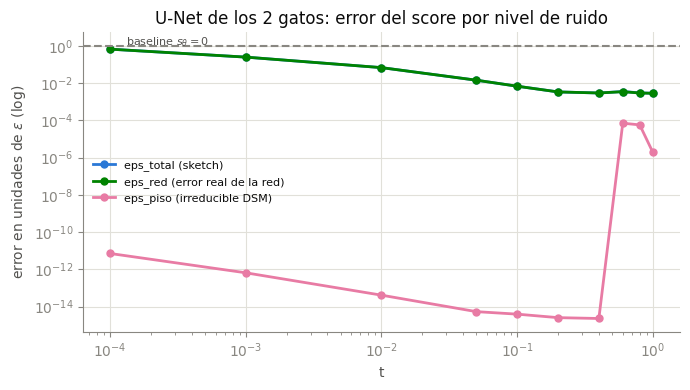

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ts = [r[0] for r in rows]
ax.plot(ts, [r[2] for r in rows], "o-", color=C_TOT, lw=2, ms=5, label="eps_total (sketch)")
ax.plot(ts, [r[3] for r in rows], "o-", color=C_NET, lw=2, ms=5, label="eps_red (error real de la red)")
ax.plot(ts, [r[4] for r in rows], "o-", color=C_FLOOR, lw=2, ms=5, label="eps_piso (irreducible DSM)")
ax.axhline(1.0, color=MUTED, ls="--", lw=1.5)
ax.text(ts[0] * 1.3, 1.1, "baseline $s_\\theta = 0$", fontsize=8, color=INK2)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("t")
ax.set_ylabel("error en unidades de $\\varepsilon$ (log)")
ax.set_title("U-Net de los 2 gatos: error del score por nivel de ruido", color=INK)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

## La causa raíz probable: el embedding de tiempo no resuelve $t$ chico

`SinusoidalEmbedding` (`models/layers.py:45`, compartido por el MLP y la U-Net) usa la convención de Transformers, `sin(t/10000^{2i/d})`, **diseñada para posiciones enteras** $0 \ldots 10^3$. Acá recibe $t \in [10^{-4}, 1]$: la frecuencia más rápida es 1 (denominador $10^0$), así que en todo el rango del proceso el argumento recorre menos de un sexto de período, y las demás componentes son aún más lentas. Consecuencia: los embeddings de $t = 10^{-4}$ y $t = 10^{-2}$ son **casi el mismo vector**, y la red no puede condicionar su salida en esa región — que es exactamente donde el error medido queda en el baseline nulo.

Lo cuantificamos con la distancia del vector de condicionamiento — el crudo (`SinusoidalEmbedding`) y el que realmente ve la U-Net (su `time_mlp` entrenado) — entre pares de $t$ que el score necesita distinguir. Contexto adicional: con muestreo uniforme de $t$, solo ~5% de los 1600 pasos de train cayeron en $t < 0.05$.

In [5]:
from diffusion.models.layers import SinusoidalEmbedding

emb_raw = SinusoidalEmbedding(embed_dim=64)   # el mismo embed_dim que la U-Net del checkpoint

pairs = [(1e-4, 1e-2), (1e-3, 1e-2), (0.01, 0.05), (0.05, 0.1), (0.2, 0.4), (0.6, 1.0)]
print(f"{'par (t, t~)':>18s} {'||Δemb|| crudo':>15s} {'||Δcond|| time_mlp':>19s}")
with torch.no_grad():
    for ta, tb in pairs:
        t2 = torch.tensor([ta, tb])
        e = emb_raw(t2)
        d_raw = (e[0] - e[1]).norm().item()
        c = model_raw.time_mlp(t2)
        d_mlp = (c[0] - c[1]).norm().item()
        print(f"({ta:8.4f}, {tb:5.2f}) {d_raw:15.4f} {d_mlp:19.4f}")

print()
print("En todo [1e-4, 1e-2] — dos órdenes de magnitud de sigma_t, score target de ~10 a ~1000 —")
print("el vector de condicionamiento apenas se mueve: la red es ciega a t en esa región.")

# Cuántos pasos de train vieron t chico (muestreo uniforme en [1e-4, 1]):
for umbral in (0.01, 0.05):
    frac = (umbral - 1e-4) / (1.0 - 1e-4)
    print(f"pasos de train (de 1600) con t < {umbral}: ~{frac * 1600:.0f}")

       par (t, t~)  ||Δemb|| crudo  ||Δcond|| time_mlp
(  0.0001,  0.01)          0.0150              2.0949
(  0.0010,  0.01)          0.0136              1.8705
(  0.0100,  0.05)          0.0605              2.6078
(  0.0500,  0.10)          0.0756              1.6872
(  0.2000,  0.40)          0.3020              3.4591
(  0.6000,  1.00)          0.6021              6.0061

En todo [1e-4, 1e-2] — dos órdenes de magnitud de sigma_t, score target de ~10 a ~1000 —
el vector de condicionamiento apenas se mueve: la red es ciega a t en esa región.
pasos de train (de 1600) con t < 0.01: ~16
pasos de train (de 1600) con t < 0.05: ~80


## Conclusiones

1. **La descomposición valida el diagnóstico:** el piso irreducible de DSM es ~0 en todos los $t$ (con 2 imágenes la posterior "¿qué gato fue?" es casi determinística salvo en $t \to 1$), así que **todo el `eps_total` es error de la red** — la columna del sketch se puede leer directamente como error del modelo.

2. **El hallazgo: la U-Net es ciega a $t$ chico.** El error en unidades de $\varepsilon$ da: $\approx 1.0$ (= baseline de no predecir nada) en $t \le 10^{-3}$, $0.74$ en $t = 0.01$, $0.14$ en $t = 0.05$, y recién memoriza de verdad a partir de $t \gtrsim 0.2$ ($0.004$–$0.012$). O sea: **la red no aprendió nada del score por debajo de $t \approx 0.01$ y poco hasta $t \approx 0.05$**, incluso evaluada sobre su propio batch de entrenamiento memorizado.

3. **Consecuencia directa sobre las muestras:** en el reverso, los pasos con $t \lesssim 0.05$ — los que hacen la limpieza final — apenas corrigen. Las muestras generadas retienen ruido residual del orden de $\sigma(0.03\text{–}0.05) \approx 0.10$–$0.17$ en unidades $[-1,1]$: el aspecto "tosco/granulado" que el notebook 06 atribuyó solo a las 2 imágenes tiene también esta causa medible. El denoising desde $t_0 = 0.4$ funciona porque el grueso ocurre en $t$ medio, donde la red sí está bien.

4. **Causa raíz (verificada como plausible, compartida entre fases):** el `SinusoidalEmbedding` con frecuencias de Transformer no distingue tiempos en $[10^{-4}, 10^{-2}]$ — el vector de condicionamiento casi no se mueve en esa región (tabla de arriba), mientras el score target cambia dos órdenes de magnitud. Es la misma capa que usa el `ScoreMLP` 2D, lo que explica también la meseta de ~35% de error a $t \lesssim 0.03$ medida en la Auditoría 2. Factores que se suman: muestreo uniforme de $t$ (solo ~80 de 1600 pasos con $t < 0.05$), sin parametrización $1/\sigma_t$ de la salida, sin EMA, y 1600 pasos en total.

5. **Qué se puede hacer (decisión del autor, no implementado):** reescalar $t$ antes del embedding (p. ej. $t \cdot 1000$, que reproduce el rango entero de DDPM) o usar Gaussian Fourier features (la elección de Song para tiempo continuo); complementos: más pasos de train, EMA, y/o muestreo de $t$ no uniforme. Cualquier cambio de embedding es cambio de red → **reentrenar todas las celdas** (la red es la variable de control del estudio).